In [220]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
import numpy as np
from scipy import linalg as la

import koala
from koala import plotting as pl
from koala.lattice import Lattice
from tqdm import tqdm

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    spectral_function,
)
from alter_morph.lattice_utilities import alter_lattice_maker

# plotting
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

Lattice(100 vertices, 150 edges)


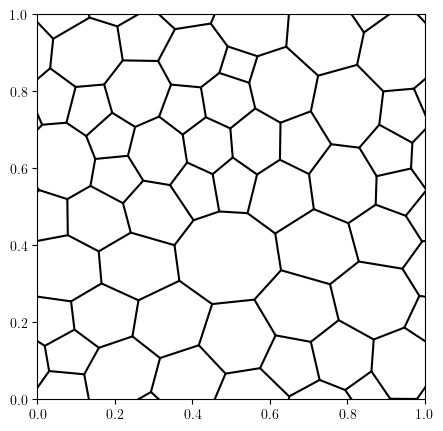

In [230]:
# generate the lattice and set the initial conditions

import koala.graph_utils


system_length = 10
lattice_type = "voronoi"
lattice = alter_lattice_maker(system_length, lattice_type)
# lattice = koala.graph_utils.cut_boundaries(lattice)

t1 = 1  # orbital parallel neighbor hopping
t2 = 1  # orbital perpendicular neighbor hopping
J = 0.3  # Interaction strength
filling = 0.5  # filling of the lattice
initial_m = np.full(lattice.n_vertices, 1.95)  # initial magnetization

initial_parameters = {
    "t1": t1,
    "t2": t2,
    "J": J,
    "filling": filling,
    "initial_m": initial_m,
}

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pl.plot_edges(lattice, ax=ax)
print(lattice)

In [ ]:
# def find_m_values(states, filling):
from alter_morph.hamiltonians import _hopping_matrix


def find_m_values(states, filling):
    """Given a set of eigenvectors, calculates the mean field values for the altermagnetic magnetic moments

    Args:
        v (np.ndarray): The eigenvectors
        filling (float): The filling fraction

    Returns:
        np.ndarray: The spatially resolved mean field values
    """

    fermi_occupation = np.linspace(0, 1, len(states)) <= filling
    # projector = states * fermi_occupation @ states.T.conj()
    local_densities = np.sum(states * states.conj() * fermi_occupation, axis=1)

    m_legend = np.tile(np.array([1, -1, -1, 1]), len(states) // 4)
    m_values = local_densities * m_legend
    m_values = m_values.reshape(-1, 4).sum(axis=-1)

    # check for complex values - this should not happen
    if not np.allclose(m_values.imag, 0):
        raise ValueError(
            "Magnetization values are complex - somewhere, somehow you fucked it up"
        )
    return m_values.real


def alt_hamiltonian(
    lattice: Lattice,
    t1: float,
    t2: float,
    J: float,
    m_values: np.ndarray,
    boundary_phase=None,
):
    """Generates an altermagnetic Hamiltonian for a given lattice

    Args:
        lattice (Lattice): The lattice to generate the Hamiltonian for
        t1 (float): Strong hopping parameter where direction matches orbital
        t2 (float): Weak hopping parameter where direction opposes orbital
        J (float): Interacting coupling parameter
        m_values (np.ndarray): Mean field values for the magnetic moments per site
        boundary_phase (np.ndarray, optional): Phase for twisted boundary conditions in x and y. Defaults to 0.

    Returns:
        np.ndarray: The Hamiltonian matrix
    """

    # basis is (up x, down x , up y, down y)

    # initialize the Hamiltonian
    ham_type = complex if boundary_phase is not None else float
    ham = np.zeros((4 * lattice.n_vertices, 4 * lattice.n_vertices), dtype=ham_type)

    # generate the hopping terms
    for n_edge in range(lattice.n_edges):
        vector = lattice.edges.vectors[n_edge]
        crossing = lattice.edges.crossing[n_edge]
        e0, e1 = lattice.edges.indices[n_edge]
        theta = np.arctan2(vector[0], vector[1])
        h0_term = np.kron(np.eye(2), _hopping_matrix(t1, t2, theta))

        # and apply boundary phase if twisting boundaries
        if boundary_phase is not None and np.any(np.nonzero(crossing)):
            phase = np.sum(boundary_phase * crossing)
            h0_term = h0_term * np.exp(1j * phase)

        ham[4 * e0 : 4 * e0 + 4, 4 * e1 : 4 * e1 + 4] = h0_term
    ham += ham.T.conj()

    # generate the onsite interaction based terms
    for n in range(lattice.n_vertices):
        vertex_neighbours = lattice.vertices.adjacent_vertices[n]
        neighbour_magnetisations = m_values[vertex_neighbours]
        total_magnetisation = np.sum(neighbour_magnetisations)
        ham[4 * n : 4 * n + 4, 4 * n : 4 * n + 4] += (
            J * total_magnetisation * np.diag(np.array([-1, 1, 1, -1]))
        )

    return ham


def single_hartree_fock_step(
    lattice: Lattice,
    initial_parameters: dict,
    m_values: np.ndarray,
    boundary_phase=None,
):
    # make and solve the Hamiltonian
    hamiltonian = alt_hamiltonian(
        lattice,
        initial_parameters["t1"],
        initial_parameters["t2"],
        initial_parameters["J"],
        m_values,
        boundary_phase,
    )
    energies, states = la.eigh(hamiltonian)

    # calculate the new magnetization values
    m_values = find_m_values(states, initial_parameters["filling"])

    return m_values


def hartree_fock(
    lattice: Lattice,
    initial_parameters: dict,
    n_steps: int,
):

    prange = tqdm(range(n_steps))
    skip_counter = 0

    m_values = np.zeros((n_steps + 1, lattice.n_vertices))
    m_values[0] = initial_parameters["initial_m"]

    for n in prange:

        m_values[n + 1] = single_hartree_fock_step(
            lattice, initial_parameters, m_values[n]
        )

        # check for convergence
        diff = np.linalg.norm(m_values[n + 1] - m_values[n])
        avg_m = np.mean(m_values[n + 1])
        prange.set_description(f"Avg:{avg_m:.2f}, diff: {diff:.6f}")

        # if the difference is small enough, we can stop
        if diff < 1e-6:
            skip_counter += 1
            if skip_counter >= 3:
                m_values = m_values[: n + 1]
                break

    return m_values


def hartree_fock_with_boundary_twisting(
    lattice: Lattice, initial_parameters: dict, n_steps: int, n_twists: int
):
    prange = tqdm(range(n_steps))
    skip_counter = 0

    m_values = np.zeros((n_steps + 1, lattice.n_vertices))
    m_values[0] = initial_parameters["initial_m"]

    k_values = np.linspace(0, 2 * np.pi, n_twists, endpoint=False)
    KX, KY = np.meshgrid(k_values, k_values)
    boundary_phases = np.stack([KX.flatten(), KY.flatten()], axis=-1)

    for n in prange:

        averaged_m = np.zeros(lattice.n_vertices)
        for k_val in boundary_phases:
            averaged_m += single_hartree_fock_step(
                lattice, initial_parameters, m_values[n], k_val
            )
        m_values[n + 1] = averaged_m / len(boundary_phases)

        # check for convergence
        diff = np.linalg.norm(m_values[n + 1] - m_values[n])
        avg_m = np.mean(m_values[n + 1])
        prange.set_description(f"Avg:{avg_m:.2f}, diff: {diff:.6f}")

        # if the difference is small enough, we can stop
        if diff < 1e-6:
            skip_counter += 1
            if skip_counter >= 3:
                m_values = m_values[: n + 1]
                break

    return m_values


m_values = hartree_fock_with_boundary_twisting(lattice, initial_parameters, 100, 1)

# m_values = hartree_fock(
#     lattice, initial_parameters, 20
# )
# hamiltonian = alt_hamiltonian(
#         lattice,
#         initial_parameters["t1"],
#         initial_parameters["t2"],
#         initial_parameters["J"],
#         m_values[-1],
#     )
# energies, states = la.eigh(hamiltonian)

# alt_hamiltonian(lattice, t1, t2, J, initial_m, np.array([0, .1]))

Avg:0.04, diff: 14.890313: 100%|██████████| 100/100 [00:10<00:00,  9.23it/s]


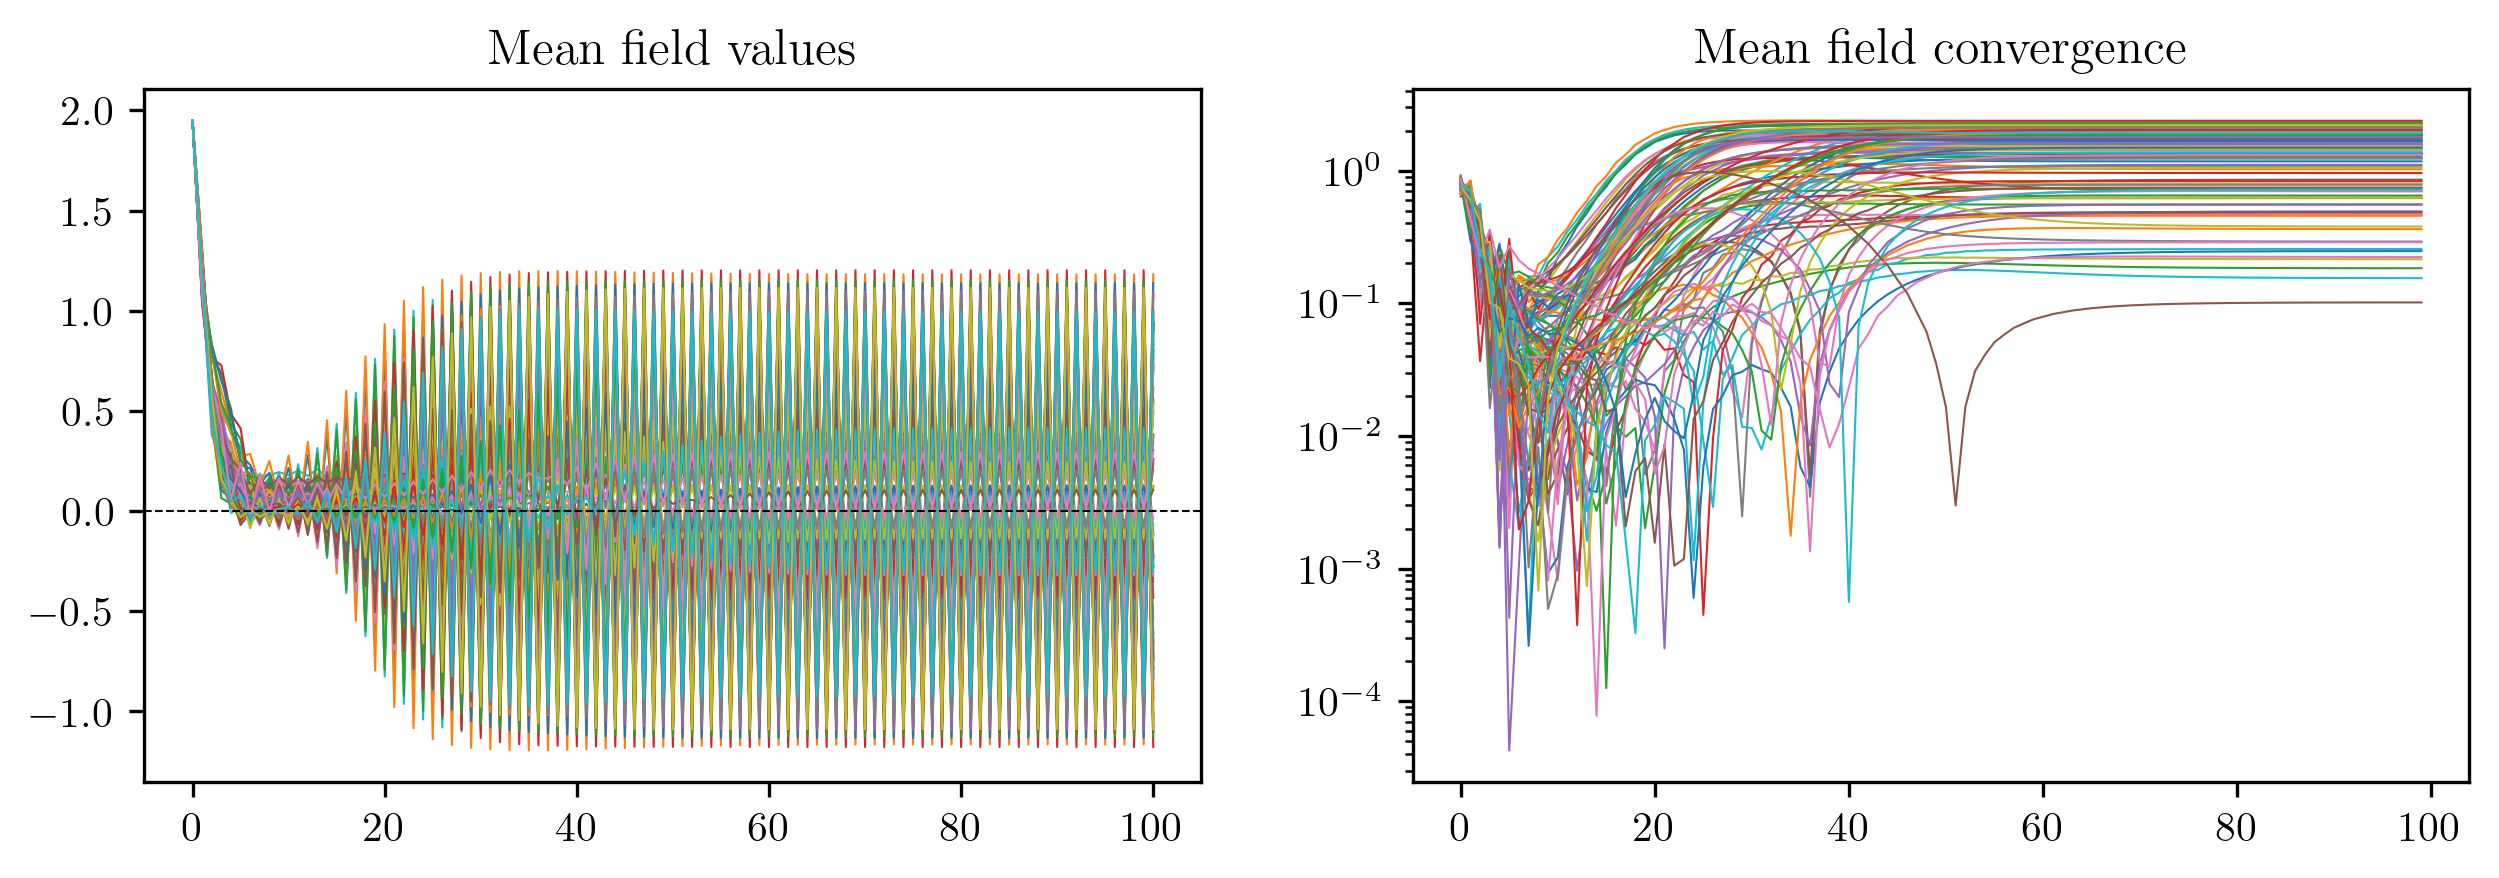

In [232]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=300)
ax[0].plot(m_values, linewidth=0.5)
ax[0].axhline(0, linestyle="--", color="black", linewidth=0.5)

diffs = np.diff(m_values, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)


ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
plt.show()

In [225]:
fermi_occupation = np.linspace(0, 1, len(energies)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = energies[n_filled_states - 1]

real_space_occupation = fermi_occupation[None, :] * (states * states.conj())
average_occupation = np.sum(real_space_occupation, axis=1)
average_occupation = (
    average_occupation[::4]
    + average_occupation[1::4]
    + average_occupation[2::4]
    + average_occupation[3::4]
)

ipr = np.sum(states**4, axis=0)

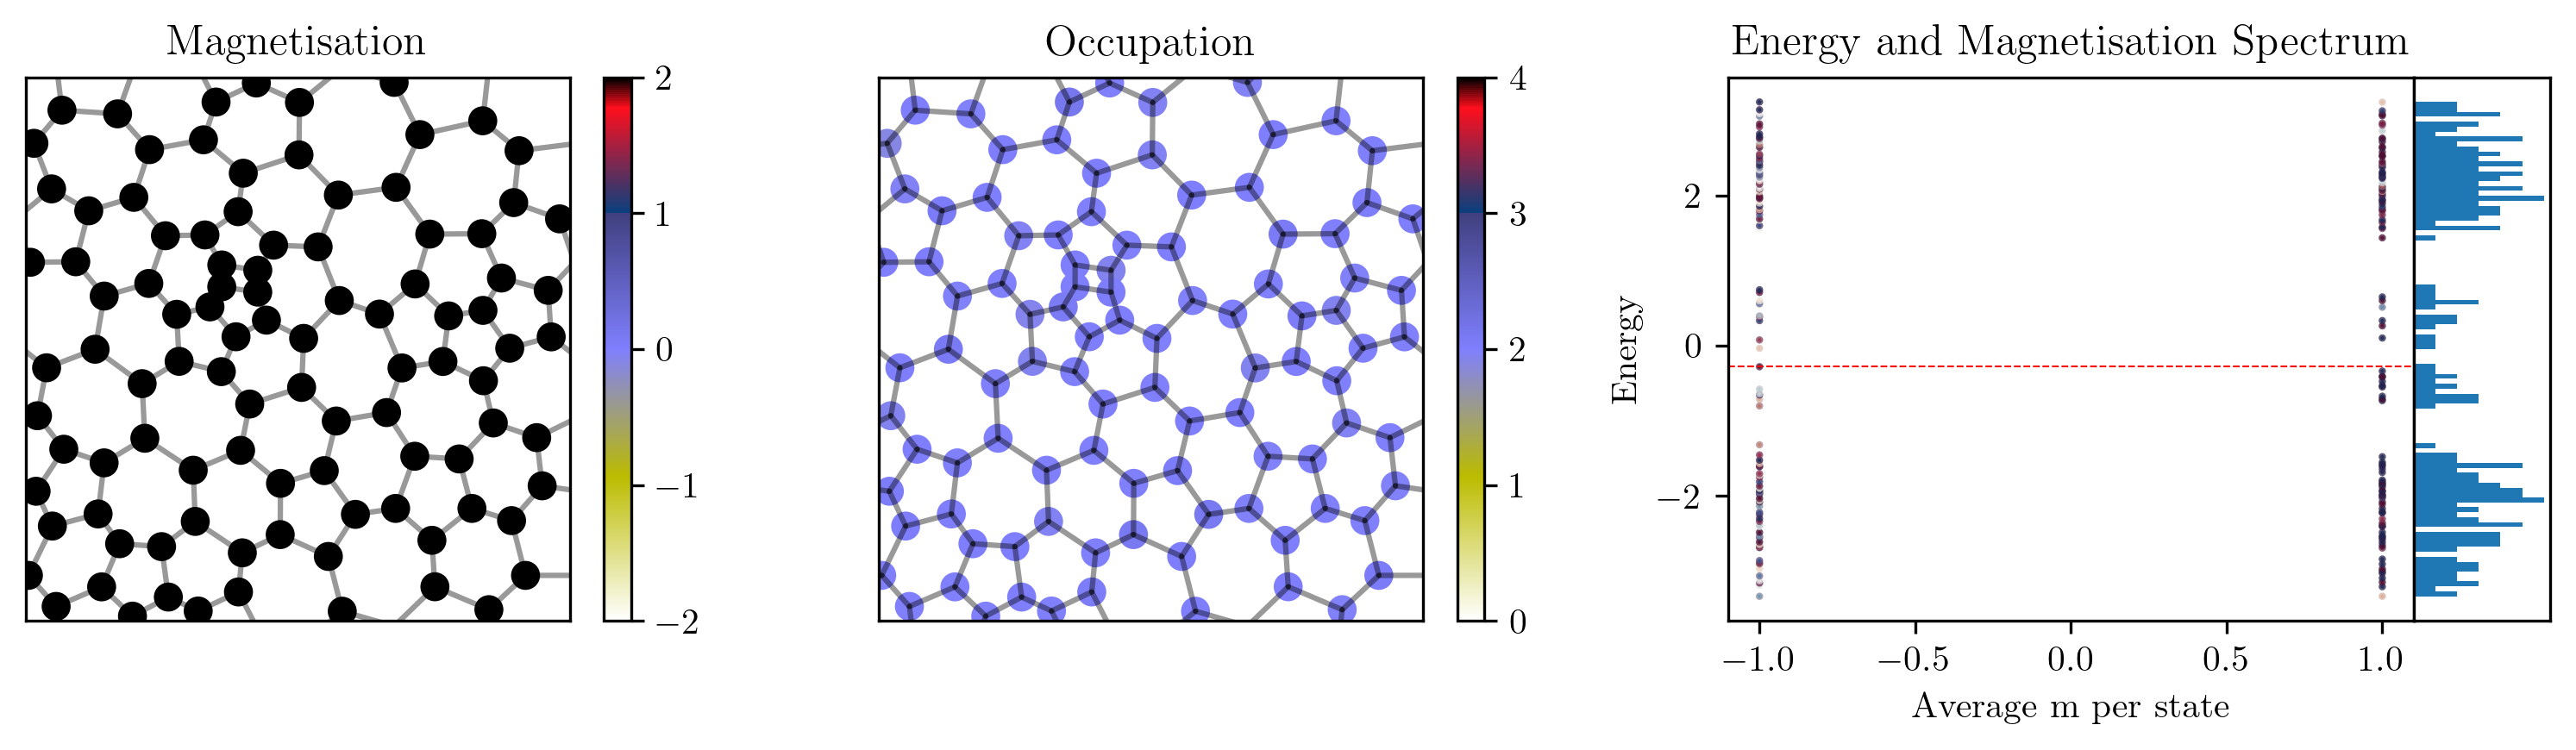

In [229]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)


average_m_per_state = find_m_per_state(states)
average_spin_per_state = find_spin_per_state(states)

m_values_out = m_values[-1]

vertices = lattice.vertices.positions
pl.plot_edges(lattice, ax=ax[0], alpha=0.4)
im = ax[0].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=m_values_out,
    cmap="gist_stern_r",
    s=50,
    vmin=-2,
    vmax=2,
)
plt.colorbar(im, ax=ax[0])
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Magnetisation")


pl.plot_edges(lattice, ax=ax[1], alpha=0.4)
im = ax[1].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=average_occupation,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=4,
)
plt.colorbar(im, ax=ax[1])
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Occupation")

im = ax[2].scatter(
    average_m_per_state, energies, s=1, c=average_spin_per_state, cmap="RdBu", alpha=0.5
)
ax[2].set_xlabel("Average m per state")
ax[2].set_ylabel("Energy")


ax_histy = ax[2].inset_axes([1.0, 0, 0.2, 1])
ax[2].axhline(fermi_energy, color="r", linestyle="--", linewidth=0.5)
ax[2].set_title("Energy and Magnetisation Spectrum")
# move ticks to left
ax[2].yaxis.tick_left()
# plt.colorbar(im, ax=ax[2], label="IPR",

ax_histy.hist(energies, bins=100, orientation="horizontal")
ax_histy.set_xticks([])
ax_histy.set_yticks([])

plt.tight_layout()

In [227]:
# find the spectral function
# def kx_ky_states(lattice, k_cutoff=30):
#     positions = lattice.vertices.positions
#     k_values = 2 * np.pi * np.arange(-k_cutoff, k_cutoff)

#     kx, ky = np.meshgrid(k_values, k_values)
#     kx = kx.flatten()
#     ky = ky.flatten()

#     rotation_matrix = np.exp(
#         1j * (kx[:, None] * positions[:, 0] + ky[:, None] * positions[:, 1])
#     )

#     # print(rotation_matrix.shape)

#     return rotation_matrix, kx, ky


omega = fermi_energy - 1
broadening = 0.1
specs = [
    spectral_function(
        lattice,
        e,
        v,
        omega,
        local_projector=np.array([1, 0, 0, 0]),
        eta=broadening,
        n_k=50,
    ),
    spectral_function(
        lattice,
        e,
        v,
        omega,
        local_projector=np.array([0, 1, 0, 0]),
        eta=broadening,
        n_k=50,
    ),
    spectral_function(
        lattice,
        e,
        v,
        omega,
        local_projector=np.array([0, 0, 1, 0]),
        eta=broadening,
        n_k=50,
    ),
    spectral_function(
        lattice,
        e,
        v,
        omega,
        local_projector=np.array([0, 0, 0, 1]),
        eta=broadening,
        n_k=50,
    ),
]

NameError: name 'e' is not defined

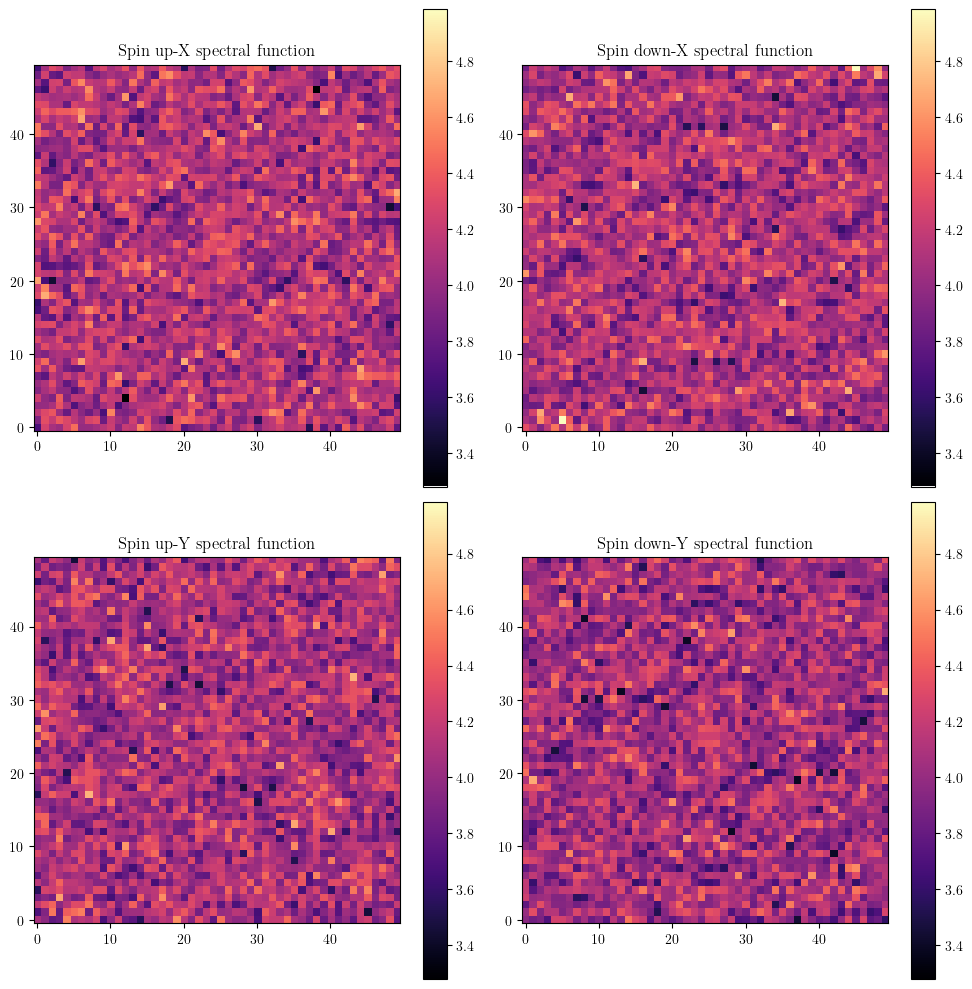

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
k_limits = 25

kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)

log_specs = np.array([np.log(np.abs(spec)) for spec in specs])

cmin = np.min(log_specs)
cmax = np.max(log_specs)

for n, a in enumerate(ax.flatten()):
    im = a.imshow(
        log_specs[n],
        cmap="magma",
        origin="lower",
        vmin=cmin,
        vmax=cmax,
    )
    # add colorbar
    plt.colorbar(im, ax=a)


ax[0, 0].set_title("Spin up-X spectral function")
ax[0, 1].set_title("Spin down-X spectral function")
ax[1, 0].set_title("Spin up-Y spectral function")
ax[1, 1].set_title("Spin down-Y spectral function")

plt.tight_layout()

[[ 35.7085134   -7.83980774  -9.48580751 ... -20.38944583 -34.67441899
   -1.6348836 ]
 [ 12.09435325   0.20224457  -5.33620753 ... -25.7312989  -42.31273921
   36.30907428]
 [-32.2553246  -27.66201979   5.83228319 ...   2.88614744   4.97025116
   -3.72143801]
 ...
 [-17.73758116  19.95251878  -6.20239396 ... -44.39765003  -9.0324547
  -14.53633484]
 [ 21.35521214  -3.72143801   4.97025116 ...   1.62590703   5.83228319
  -27.66201979]
 [  6.31606155  36.30907428 -42.31273921 ...  10.5231245   -5.33620753
    0.20224457]]


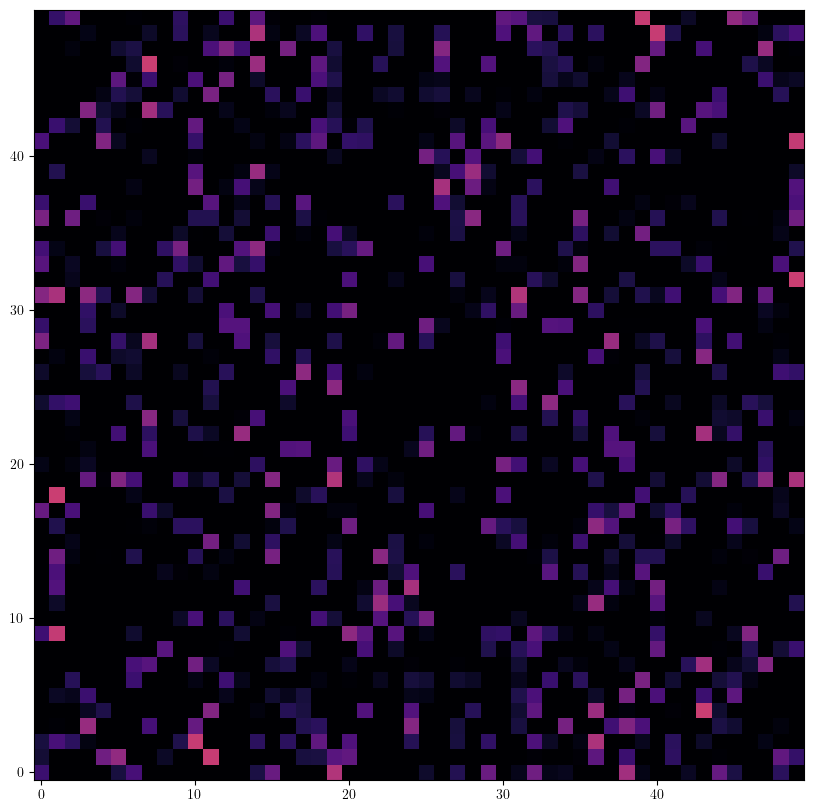

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
k_limits = 25
kx = np.arange(-k_limits, k_limits)
ky = np.arange(-k_limits, k_limits)

log_specs = np.array([np.log(np.abs(spec)) for spec in specs])

subtracted = specs[0] - specs[1] + specs[2] - specs[3]
# log_sub = np.log(np.abs(subtracted))
print(subtracted.imag)
cmin = np.min(log_specs)
cmax = np.max(log_specs)


im = ax.imshow(
    np.log(np.abs(subtracted)),
    cmap="magma",
    origin="lower",
    vmin=cmin,
    vmax=cmax,
)